# L5d Lab: Assigning Faculty to Courses as a Minimum-Cost Flow

Every semester, a department must decide who teaches what. Faculty owe a set number of courses, some courses need a team, and a survey records how prepared each person is to teach each course. We will find the schedule that follows every rule and best matches the survey, then change the data and watch how the schedule responds.

This lab applies the minimum-cost flow model from the [L5c lecture](../L5c/CHEME-5800-L5c-Lecture-LinearProgramming-Fall-2026.ipynb) to a teaching-assignment problem modeled on the tool our department uses, with synthetic data. In the [L5b lab](../L5b/CHEME-5800-L5b-Lab-MaximumFlowSensitivity-Fall-2026.ipynb), we maximized the number of assignments. Here, the teaching loads fix that number, and we minimize the total survey score among schedules that satisfy the department's rules.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Translate rules into bounds and costs:__ Express teaching loads, staffing limits, fixed assignments, and survey scores as lower bounds, capacities, and costs on a flow network. Explain why a blank survey entry removes an edge while a poor score only makes it expensive.
> * __Build and solve the linear program:__ Assemble the incidence matrix, required net flows, costs, and bounds, and solve for the lowest-cost schedule. Read the assignments from the edge flows and check them against the department's rules.
> * __Predict the effect of changes:__ Predict how the schedule responds when a survey score, a load, or another rule changes, and check the prediction against the flow diagram. Explain why a change in cost reranks the same schedules while a change in a bound can remove them.

In this lab, we build the network from the department's tables, solve the linear program, and then change the data live, predicting each new schedule before we solve. The code is complete, and each task ends with discussion of what the model tells us.

Let's get started!

___

## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the course library, this lab's department, flow-model, and plotting helpers, and the packages used here.

Let's set up our code environment:

In [1]:
# Load packages, data paths, and lab functions -
include(joinpath(@__DIR__, "Include.jl")) # @__DIR__ locates this notebook's setup file

# Choose the plot appearance -
# After changing the theme, rerun this cell and the plotting cells.
# A single figure can override this choice with the keyword theme = :dark.
theme(:default)   # light background
# theme(:dark)   # dark background

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5800 course library documentation](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/) for the functions and types used here.

The four CSV files in the [data folder](data/README.md) hold faculty loads, course staffing limits, survey scores, and fixed assignments. The course codes are real; the faculty, A through J, and their data are synthetic. The lab's functions are complete and live in [src/Compute.jl](src/Compute.jl).

__Optional exercise:__ After class, rebuild [the `build_teaching_network(...)` function](docs/build_teaching_network.md) from its docstring, restart the kernel to load your changes, and rerun the notebook; the reference is in [src/Compute-solution.jl](src/Compute-solution.jl).

___

## Task 1: Build the teaching-assignment network

In this task, we read the department's tables and translate its teaching rules into a flow network. We first identify the assignments the department allows, then use edge bounds to express how many courses each faculty member must teach and how many instructors each course needs.

### The department's tables

[The `read_department(...)` function](docs/read_department.md) reads the four CSV files and checks that the faculty names, course codes, and survey entries agree. It returns `department`, which holds the faculty, course, and survey tables, together with the list of fixed assignments. For example, `department.courses` contains one row per course; its `min_faculty` and `max_faculty` columns give the smallest and largest permitted teaching teams.

Let's read the data and display the course staffing limits. Equal limits prescribe an exact team size, while a minimum of zero allows a course to remain unstaffed:

In [2]:
# Read and validate the department data -
department = read_department(CHEME5800_L5D_DATA); # loads, staffing bounds, scores, and fixed pairs

# Display the staffing rules -
# Select all course rows and only the four columns needed to interpret the bounds.
pretty_table(department.courses[:, [:course, :title, :min_faculty, :max_faculty]];
    backend = :text, # plain-text output remains readable in either notebook theme
    table_format = TextTableFormat(borders = text_table_borders__compact),
    column_labels = ["Course", "Title", "Minimum", "Maximum"],
    alignment = [:l, :l, :r, :r], # left-align names and right-align staffing counts
    fit_table_in_display_horizontally = false, # print every column
)

 ------------ ---------------------------------------------------------------------- --------- ---------
  Course       Title                                                                  Minimum   Maximum 
 ------------ ---------------------------------------------------------------------- --------- ---------
  ENGRI-1120   Feast! Chemical and Biomolecular Processes and Products through Food         2         2
  ENGRD-2190   Chemical Process Design and Analysis                                         1         1
  CHEME-2880   Biomolecular Engineering: Fundamentals and Applications                      1         1
  CHEME-3130   Chemical Engineering Thermodynamics                                          1         1
  CHEME-3240   Heat and Mass Transfer                                                       1         1
  CHEME-4320   Chemical Engineering Capstone Design I                                       3         3
  CHEME-5310   Principles of Electrochemical Engineering     

Six core courses need one instructor each, the capstone CHEME 4320 needs a team of three, and ENGRI 1120 needs two. The four electives need zero or one instructor, so the model can leave some electives out of the schedule. A team-taught course uses one teaching assignment from each member of its team.

Next, we combine the faculty loads with the survey table. Each row describes one faculty member: `Load` is the exact number of assignments they must receive, and each numbered course column gives their survey score. The display code converts the scores to text so missing entries remain visibly blank. It does not replace missing scores in `department.preferences`:

In [3]:
# Prepare the survey for display -
# Convert scores to strings so missing options can appear as empty cells.
# Not(:name) omits the repeated faculty-name column; department keeps the numeric data.
scores = mapcols(column -> [ismissing(value) ? "" : string(value) for value in column],
    department.preferences[:, Not(:name)]);
survey_table = hcat(department.faculty, scores); # join loads and scores in the validated faculty order

# Display the complete survey -
pretty_table(survey_table;
    backend = :text,
    table_format = TextTableFormat(borders = text_table_borders__compact),
    # Shorten course codes in the display only: CHEME-2880 becomes 2880.
    column_labels = vcat(["Faculty", "Load"], replace.(department.courses.course, r"^[A-Z]+-" => "")),
    alignment = :c,
    fit_table_in_display_horizontally = false, # keep all course scores visible
)

 --------- ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------
  Faculty   Load   1120   2190   2880   3130   3240   4320   5310   6110   6230   6310   6440   6800 
 --------- ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------
     A       2             0             1             0                                         2
     B       1      1             0             2                                  0
     C       1                           0             2      2      1
     D       2             2                    0      1             1      0
     E       1      2                    1             1      0
     F       2             1                           3             1                    2      0
     G       1      0                                                              2      1
     H       1      2                           1      1                    1             0
     I       1

The survey records 0 for prepared to teach, 1 for comfortable teaching, 2 for interested in developing expertise, and 3 for needing significant support or lead time. We use these numbers as additive costs: a smaller total is preferred by this model. A blank means the faculty–course pairing is not an option, rather than an expensive option.

Read faculty member A's row as an example. A owes two assignments and has four available courses, but the [fixed-assignment table](data/Assignments.csv) requires one of those assignments to be CHEME 4320. The loads across all ten faculty add up to 13 assignments. Notice also that only B has a score for CHEME 2880; this restriction will matter when we change B's load.

### From rules to a network

One unit of flow along source → faculty member → course → completion → sink is one teaching assignment. For example, source → A → CHEME 4320 → its completion node → sink assigns A to the capstone. The same unit passes through all four edges; it counts as one assignment, not four.

Conservation requires each faculty member to pass their incoming load to courses. At a course node, the assignments from its instructors combine and pass through a single staffing edge to the completion node. Bounding this edge limits the size of the whole teaching team. The completion node then passes that same flow to the sink, retaining the network layout used in L5a and L5b. Each rule sets the bounds or the cost of one kind of edge:

| Rule | Edge $j$ | Lower bound $\ell_j$ | Capacity $c_j$ | Cost $w_j$ per assignment |
|---|---|---|---|---|
| Exact teaching load | source → faculty node $i$ | $L_i$ | $L_i$ | 0 |
| Survey score | faculty node $i$ → course node $k$ | 0 | 1 | survey score |
| Blank survey entry | no edge | | | |
| Fixed assignment | faculty node $i$ → course node $k$ | 1 | 1 | survey score |
| Staffing bounds | course node $k$ → its completion node | $m_k$ | $M_k$ | 0 |
| Course completion | completion node → sink | 0 | $M_k$ | 0 |

Here $L_i$ is the load of the faculty member at node $i$, and $m_k$ and $M_k$ are the staffing limits of the course at node $k$. As in the L5c lecture, $c_j$ is the capacity and $w_j$ the cost of edge $j$; the lower bound $\ell_j$ is new. Equal bounds force a flow, so each load is met exactly and the fixed assignment must appear. A faculty-to-course capacity of one prevents the same person from filling two positions on one teaching team. Only faculty-to-course edges have nonzero costs, so an assignment contributes its survey score once to the objective.

[The `build_teaching_network(...)` function](docs/build_teaching_network.md) builds `network` from these rules. Node 1 is the source, nodes 2–11 are faculty A–J, nodes 12–23 are the courses, nodes 24–35 are their completion nodes, and node 36 is the sink. The returned `network.edges` records each edge's endpoints, lower and upper bounds, and cost. Its name-to-node dictionaries let us locate a faculty member or course without remembering these node numbers.

The next cell constructs this network and counts its edges by role. It also reports `required_flow`, the total teaching load that must reach the sink:

In [4]:
# Translate the department rules into edges with bounds and costs -
network = build_teaching_network(department); # one unit of flow represents one assignment

# Count the nodes and each kind of edge -
number_of_faculty = nrow(department.faculty); # one load edge per faculty member
number_of_courses = nrow(department.courses); # one staffing and one completion edge per course
# Subtract the three other edge groups to count the available faculty-course options.
(nodes = length(network.labels),
 load_edges = number_of_faculty,
 option_edges = length(network.edges) - number_of_faculty - 2number_of_courses,
 staffing_edges = number_of_courses,
 completion_edges = number_of_courses,
 required_flow = network.required_flow) # F: sum of the faculty teaching loads, in assignments

(nodes = 36, load_edges = 10, option_edges = 42, staffing_edges = 12, completion_edges = 12, required_flow = 13.0)

Only 42 of the 120 faculty–course pairs have survey scores. Together with 10 load edges, 12 staffing edges, and 12 completion edges, they give 76 edges and a required flow of 13 assignments.

Before solving, let's inspect the available routes with [the `plot_teaching_flow(...)` function](docs/plot_teaching_flow.md). Gray arrows show the network's edges, while blue marks A's fixed assignment. No schedule has been selected yet. Trace A's route to the capstone and B's route to CHEME 2880, then locate the staffing edges between the course boxes and their completion nodes:

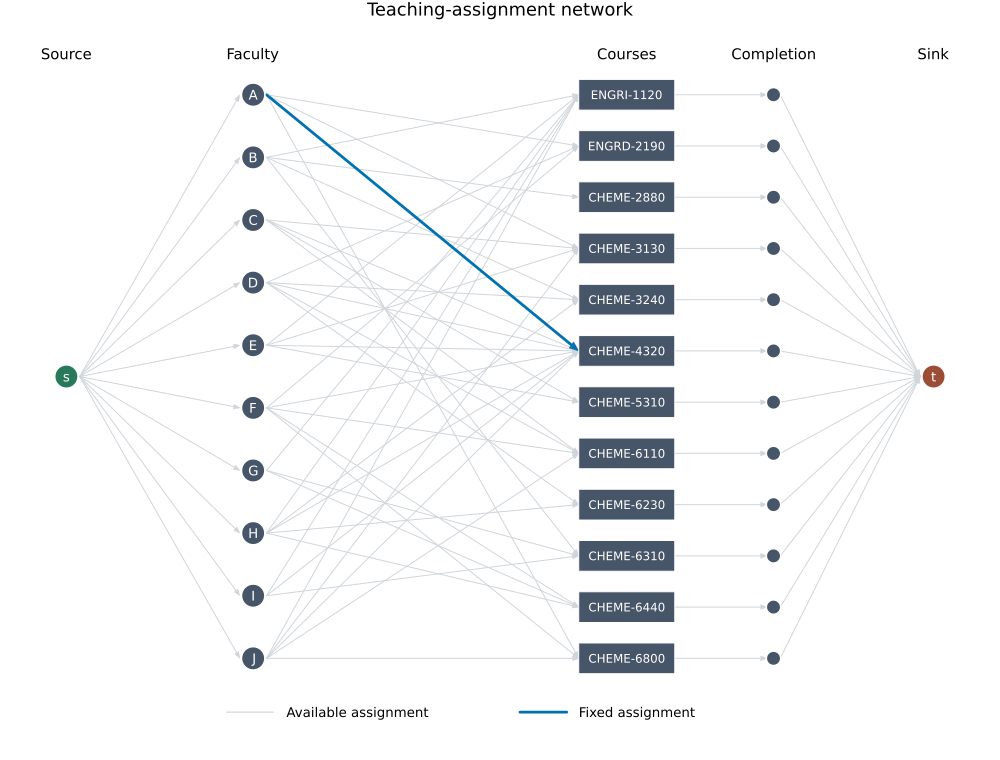

In [5]:
# Inspect the network before solving -
# With no result argument, the plot shows available options and fixed assignments.
plot_teaching_flow(department, network; title = "Teaching-assignment network")

### Check the totals before solving

Every assignment uses one unit of some faculty member's load and fills one staffing position. So with $F=\sum_i L_i$, the total load, every feasible schedule must satisfy:

$$
\sum_{k}m_k\;\leq\;F\;\leq\;\sum_{k}M_k.
$$

If the total load is smaller than the minimum staffing, some required position must remain empty. If it exceeds the maximum staffing, some faculty load cannot be assigned. [The `staffing_totals(...)` function](docs/staffing_totals.md) returns the total load, the two staffing totals, and `totals_ok`, which reports whether this necessary condition holds:

In [6]:
# Check whether the total load fits between the total staffing limits -
# This necessary check ignores which faculty can teach each course; it cannot prove feasibility.
totals = staffing_totals(department)

(total_load = 13, total_min = 11, total_max = 15, totals_ok = true)

The 13 assignments fit between 11 and 15 staffing positions. The totals check passes, but it does not establish that a schedule exists: it has not considered which faculty can teach which courses. The linear program must satisfy those restrictions as well as the totals.

### Things to think about

__Can we replace every blank survey entry with a score of 3?__ Suppose the department proposes this change because it wants the solver to consider more assignments. Use the survey table and network to explain what would change in the model. Begin with CHEME 2880: identify who can teach it now and which new arrows would appear under the proposed rule. Then explain whether a high cost prevents an assignment or merely makes the solver prefer other choices when they are feasible. Your argument should distinguish a faculty member who needs support from a pairing the department has not approved, and explain which interpretation the revised network would enforce.

___

## Task 2: Formulate and solve the linear program

In this task, we assemble the linear program from the network, solve for a minimum-cost schedule, and check the returned assignments against the department's rules. We develop the minimum-cost-flow formulation from [the L5c lecture](../L5c/CHEME-5800-L5c-Lecture-LinearProgramming-Fall-2026.ipynb) here, starting with what the solver chooses and what the department has already specified.

### From assignments to a linear program

The network is a directed graph $G=(\mathcal{V},\mathcal{E})$, where $\mathcal{V}$ contains the nodes and $\mathcal{E}$ contains the directed edges. Our department produces 36 nodes and 76 edges. The __decision variable__ $f_j$ is the flow on edge $j$, measured in assignments. On a faculty-to-course edge, a flow of one selects that pairing. The load, staffing, and completion edges carry those same assignments through the other layers of the network.

The department supplies three numbers for each edge: a lower bound $\ell_j$, an upper bound or capacity $c_j$, and a cost $w_j$ per assignment. These are fixed inputs. The solver chooses the 76 entries of the flow vector $\mathbf{f}$, subject to the bounds and to conservation at every intermediate node. The required source-to-sink flow is already fixed at $F=13$ by the total teaching load; we are choosing how to distribute those assignments.

We express all node balances together using the __node–edge incidence matrix__ $\mathbf{A}$ and the prescribed net inflow vector $\mathbf{b}$. There is one row of $\mathbf{A}$ per node and one column per edge. We will construct this matrix shortly. The minimum-cost-flow linear program is given by:

$$
\begin{aligned}
\underset{\mathbf{f}}{\text{minimize}}\quad
    & \mathbf{w}^{\top}\mathbf{f}=\sum_{j\in\mathcal{E}}w_j f_j\\
\text{subject to}\quad
    & \mathbf{A}\mathbf{f}=\mathbf{b},\\
    & \ell_j\leq f_j\leq c_j,\qquad j\in\mathcal{E}.
\end{aligned}
$$

The objective adds the survey scores of the selected assignments; the other network edges have zero cost, so each assignment contributes its score once. The equality constraints enforce the required source and sink flows and conservation at intermediate nodes. The bounds enforce teaching loads, staffing limits, and fixed assignments. The lecture's zero lower bound is a special case: positive lower bounds let us require an assignment or a minimum staffing level.

This is a __linear program__ because the objective and constraints contain only sums of flow variables multiplied by fixed coefficients. A flow vector is __feasible__ when it satisfies every balance and bound. It is __optimal__ when no feasible flow vector has a smaller objective value. A low-cost collection of pairings is not a valid schedule if it leaves a required course unstaffed or exceeds someone's teaching load.

We will construct each array explicitly so we can relate the solver's inputs to these rules. The cost and bound vectors have 76 entries, the incidence matrix has 36 rows and 76 columns, and the balance vector has 36 entries.

### Bounds and costs

We read $\ell_j$, $c_j$, and $w_j$ from the edges into `lower`, `capacity`, and `w`. Each bracketed expression visits the edges in order and collects one field. For example, `[edge.cost for edge in network.edges]` collects their costs. Entry `j` in all three arrays must describe the same edge as column `j` of the incidence matrix; otherwise the solver would apply a cost or bound to the wrong assignment:

In [7]:
# Collect one entry per edge, preserving network.edges order -
# Entry j must refer to the same edge in all three vectors and in column j of A.
lower = [edge.lower for edge in network.edges]; # ℓ_j: minimum flow, in assignments
capacity = [edge.upper for edge in network.edges]; # c_j: maximum flow, in assignments
w = [edge.cost for edge in network.edges]; # w_j: survey-score points per assignment

Let's check this translation on faculty member A and the capstone before building the rest of the model. The next cell attaches endpoint names to each edge's bounds and cost. The `shown` array selects A's incoming load edge, A's available assignments, and the capstone's staffing and completion edges. Compare these rows with A's load, the fixed-assignment rule, and the capstone's required team size:

In [8]:
# Label the edge data so we can compare the arrays with the department's rules -
edge_table = DataFrame(
    edge = ["$(network.labels[edge.source]) → $(network.labels[edge.target])" for edge in network.edges],
    lower = lower, capacity = capacity, cost = w, # each table row describes one incidence column
);

# Select faculty member A's edges and the capstone's staffing and completion edges -
node_A = network.faculty_node["A"]; # node identifier for faculty member A
node_capstone = network.course_node["CHEME-4320"]; # node identifier for the capstone course
node_capstone_done = network.completion_node["CHEME-4320"]; # node that passes capstone flow to the sink
shown = [edge.source in (node_A, node_capstone, node_capstone_done) || edge.target == node_A
    for edge in network.edges]; # one Boolean per edge; include A's incoming load edge as well

# Display the selected rows with their lower bounds, capacities, and costs -
pretty_table(edge_table[shown, :];
    backend = :text,
    table_format = TextTableFormat(borders = text_table_borders__compact),
    column_labels = ["Edge", "Lower bound ℓ", "Capacity c", "Cost w"],
    alignment = [:l, :r, :r, :r],
)

 ------------------------------------ --------------- ------------ --------
  Edge                                 Lower bound ℓ   Capacity c   Cost w 
 ------------------------------------ --------------- ------------ --------
  source → A                                     2.0          2.0      0.0
  A → ENGRD-2190                                 0.0          1.0      0.0
  A → CHEME-3130                                 0.0          1.0      1.0
  A → CHEME-4320                                 1.0          1.0      0.0
  A → CHEME-6800                                 0.0          1.0      2.0
  CHEME-4320 → CHEME-4320 completion             3.0          3.0      0.0
  CHEME-4320 completion → sink                   0.0          3.0      0.0
 ------------------------------------ --------------- ------------ --------


A's load edge has $\ell_j=c_j=2$, the fixed edge to CHEME 4320 has $\ell_j=c_j=1$, and the capstone's staffing edge has $\ell_j=c_j=3$, the team size.

### Required net flows

The vector $\mathbf{b}$ prescribes net inflow, meaning inflow minus outflow, at each node. The source $s$ supplies one unit per assignment, so its entry is negative; the sink $t$ collects those units, so its entry is positive. Let $L_i$ be the teaching load of the faculty member at node $i$. Summing over the faculty nodes gives a required total flow of $F=\sum_i L_i=13$ assignments. The entries of $\mathbf{b}$ are given by:

$$
b_i=\begin{cases}
-F, & i=s\quad\text{(source supplies the assignments)},\\
F, & i=t\quad\text{(sink collects the assignments)},\\
0, & \text{otherwise}\quad\text{(inflow equals outflow)}.
\end{cases}
$$

A faculty node has zero net inflow even when its teaching load is positive. Its incoming load edge supplies the assignments, and its outgoing course edges distribute them; conservation requires the two totals to agree. Course and completion nodes also pass on all the flow they receive. Only the source and sink exchange flow with the outside of this network.

In the next cell, `b` starts as a vector of zeros with one entry per node. We set only its source and sink entries, then display them to check their signs and magnitudes:

In [9]:
# Prescribe inflow minus outflow at every node -
b = let
    F = network.required_flow; # total teaching load, in assignments
    b = zeros(length(network.labels)); # intermediate nodes conserve flow: net inflow is zero
    b[network.source] = -F; # the source sends F more units than it receives
    b[network.sink] = F; # the sink receives F more units than it sends
    b # return the local vector as the value of the let block
end;

# Inspect the supply and demand entries; their sum must be zero -
(required_flow = network.required_flow, source_entry = b[network.source], sink_entry = b[network.sink])

(required_flow = 13.0, source_entry = -13.0, sink_entry = 13.0)

### The incidence matrix

How do we turn a directed edge into a balance equation? Each unit of flow on that edge leaves one node and enters another. The corresponding column of $\mathbf{A}$ must subtract that flow at its starting node and add it at its ending node. For node $i$ and edge $j$, we define the matrix entry by:

$$
A_{ij}=\begin{cases}
-1, & \text{edge }j\text{ leaves node }i,\\
1, & \text{edge }j\text{ enters node }i,\\
0, & \text{edge }j\text{ is not incident to node }i.
\end{cases}
$$

The matrix contains the network's connections and directions. Costs and bounds belong in their separate vectors. Multiplying row $i$ by the flow vector adds the incoming flows and subtracts the outgoing flows, so the row balance is given by:

$$
(\mathbf{A}\mathbf{f})_i
=\sum_{j:\,j\text{ enters }i}f_j
-\sum_{j:\,j\text{ leaves }i}f_j
=b_i.
$$

__Work through a small network.__ Consider the three-node example from L5c before assembling our 36-node teaching network. Edge 1 goes from $s$ to $v$, edge 2 goes from $v$ to $t$, and edge 3 goes directly from $s$ to $t$. For this small example only, suppose we must deliver $F=3$ units. Order the rows as $(s,v,t)$ and the columns as edges $(1,2,3)$. The balance equations are then given by:

$$
\underbrace{\begin{bmatrix}
-1&0&-1\\
1&-1&0\\
0&1&1
\end{bmatrix}}_{\mathbf{A}}
\underbrace{\begin{bmatrix}f_1\\f_2\\f_3\end{bmatrix}}_{\mathbf{f}}
=\underbrace{\begin{bmatrix}-3\\0\\3\end{bmatrix}}_{\mathbf{b}}.
$$

Read this matrix in both directions. Column 1 has a minus one at $s$ and a plus one at $v$, exactly the endpoints of edge 1. Row 1 requires $f_1+f_3=3$ units to leave the source. Row 2 requires $f_1=f_2$ at the intermediate node. Row 3 requires $f_2+f_3=3$ units to enter the sink. __Columns describe edges; rows describe node balances.__

Conservation still leaves a choice between the two routes. Suppose edges 1 and 2 each have capacity 2 and cost 1 dollar per unit, while edge 3 has capacity 3 and cost 5 dollars per unit; all lower bounds are zero. The route through $v$ costs 2 dollars per delivered unit, so we fill its two-unit capacity and send the remaining unit directly. The optimal flows are $(f_1,f_2,f_3)=(2,2,1)$, with cost $2+2+5=9$ dollars. Sending all three units directly also satisfies the balances and bounds, but costs 15 dollars. The constraints determine which flows are feasible; the objective determines which feasible flows are preferred.

__Return to the teaching network.__ We apply exactly the same incidence rule to its 76 edges. For example, the column for B → CHEME 2880 has a minus one in B's row, a plus one in the course's row, and zeros elsewhere. B's full row also includes the incoming load edge and any other outgoing course options. Its equation requires the sum of B's course assignments to equal the flow on B's load edge, which the bounds fix at B's required load.

We initialize `A` with one row per node and one column per edge. The loop visits each edge together with its index `j`, placing the two nonzero entries in that column. Node identifiers equal row indices in this network, so `edge.source` and `edge.target` select the required rows directly:

In [10]:
# Assemble the incidence matrix one edge column at a time -
A = let
    A = zeros(length(network.labels), length(network.edges)); # rows: nodes; columns: edges
    # Node identifiers equal row indices in this network; j is the edge's position.
    for (j, edge) in enumerate(network.edges)
        A[edge.source, j] = -1.0; # f_j is subtracted from the node where this edge begins
        A[edge.target, j] = 1.0; # f_j is added to the node where this edge ends
    end
    A # all other entries stay zero; the completed matrix is returned from the let block
end;

Before solving, we check the array dimensions and two consequences of conservation. Every column of $\mathbf{A}$ should sum to zero because an edge leaves one node and enters another. The entries of $\mathbf{b}$ should also sum to zero because the sink collects exactly what the source supplies.

We compare our matrix with the one returned by [the `flow_formulation(...)` function](docs/flow_formulation.md), which assembles the same model from the edge records. These are assembly checks; they do not establish feasibility or optimality. Finally, we print the nonzero entries in the row for CHEME 2880 so we can interpret one balance directly:

In [11]:
# Check matrix dimensions, conservation signs, and agreement with the assembly helper -
@testset "Linear program arrays" begin
    @test size(A) == (length(network.labels), length(network.edges)) # node rows and edge columns
    @test all(sum(A; dims = 1) .== 0.0) # sum down each column: one -1 and one +1
    @test sum(b) == 0.0 # total supply equals total demand
    @test A == flow_formulation(network.edges, network.source, network.sink, network.required_flow).A
end;

# Read one conservation equation directly from its nonzero coefficients -
row_2880 = network.course_node["CHEME-2880"]; # the material and energy balances course
# findall returns the incident edge indices; attach their labels to the +1 or -1 coefficients.
[(edge = edge_table.edge[j], entry = A[row_2880, j]) for j in findall(!iszero, A[row_2880, :])]

Test Summary:         | Pass  Total  Time
Linear program arrays |    4      4  0.5s


2-element Vector{@NamedTuple{edge::String, entry::Float64}}:
 (edge = "B → CHEME-2880", entry = 1.0)
 (edge = "CHEME-2880 → CHEME-2880 completion", entry = -1.0)

The row for CHEME 2880 has just two nonzero entries: a plus one for flow from B and a minus one for flow to the course's completion node. Since this course has zero required net inflow, those two flows must be equal. Its staffing edge has both bounds equal to one, so B must supply one assignment. This is a consequence of the network's connections and bounds, before we minimize any cost.

### Solve the linear program

[The `solve_flow_lp(...)` function](docs/solve_flow_lp.md) passes our arrays to JuMP and the GLPK solver. It returns `result`, which contains the termination status, the edge flows, and the objective value when a solution is optimal. The next cell displays the status and total cost. We need `OPTIMAL` before interpreting a minimum-cost schedule; an `INFEASIBLE` result has no schedule to read:

In [12]:
# Solve min wᵀf subject to Af = b and lower ≤ f ≤ capacity -
result = solve_flow_lp(network, A, b, w, lower, capacity); # JuMP model solved by GLPK

# Check status before interpreting flows; a nonoptimal result has no reported schedule or cost -
(status = result.status, total_cost = result.cost) # cost is measured in survey-score points

(status = OPTIMAL, total_cost = 5.0)

For the supplied data, the solver reports `OPTIMAL` with a total cost of 5 survey-score points. To turn the flow vector into a schedule, we read only the faculty-to-course edges: a flow of one selects that pairing, while a flow of zero leaves it unused. The load, staffing, and completion edges carry the same assignments through the network and should not be counted as separate teaching decisions.

[The `teaching_schedule(...)` function](docs/teaching_schedule.md) produces one row per selected faculty–course pairing and retains its survey score and flow. We store this table in `schedule`, then use [the `assignments_by_faculty(...)` function](docs/assignments_by_faculty.md) to group the course names and scores by faculty member. Compare the number of listed courses with each person's load:

In [13]:
# Extract faculty-to-course flows as assignment rows -
schedule = teaching_schedule(department, network, result); # retain unrounded flows and survey scores

# Group assignments by faculty member to compare the schedule with the survey -
pretty_table(assignments_by_faculty(department, schedule);
    backend = :text,
    table_format = TextTableFormat(borders = text_table_borders__compact),
    column_labels = ["Faculty", "Load", "Courses", "Scores"], # course and score lists have matching order
    alignment = [:c, :r, :l, :l],
)

 --------- ------ ------------------------ --------
  Faculty   Load   Courses                  Scores 
 --------- ------ ------------------------ --------
     A         2   ENGRD-2190, CHEME-4320   0, 0
     B         1   CHEME-2880               0
     C         1   CHEME-3130               0
     D         2   CHEME-3240, CHEME-6230   0, 0
     E         1   CHEME-4320               1
     F         2   CHEME-6110, CHEME-6800   1, 0
     G         1   ENGRI-1120               0
     H         1   CHEME-4320               1
     I         1   CHEME-6310               0
     J         1   ENGRI-1120               2
 --------- ------ ------------------------ --------


Everyone teaches their full load in the displayed schedule. Most selected scores are zero; E, F, and H each contribute one point, and J contributes two, giving a total cost of 5. The solver minimizes this sum across the department, so a low total does not mean every individual receives a low-score assignment.

### Check the schedule against the model and the department

Before relying on the schedule, we check the returned flows independently with [the `validate_flow_solution(...)` function](docs/validate_flow.md). It checks each edge against its bounds, accumulates node balances directly from the edge endpoints, and recomputes the cost. This verifies that the flows satisfy the model we supplied and that the reported objective agrees with those flows.

[The `schedule_checks(...)` function](docs/schedule_checks.md) checks the same result in the department's terms: each faculty member receives the required load and each course satisfies its staffing bounds. We also check the fixed assignments explicitly.

Finally, the flows must describe whole assignments. For a network incidence matrix with integer bounds and required net flows, every corner of the feasible region has integer flows. The simplex solver returns an optimal corner, so this linear program gives whole assignments without declaring integer decision variables. We still check the returned values to allow for numerical error; we do not round a fractional schedule into an apparently valid one.

The following tests use an absolute tolerance of `1e-8` assignments for flow comparisons and `1e-8` score points for the cost comparison. A passing result verifies the returned schedule's feasibility and cost; the solver's `OPTIMAL` status supplies its optimality claim:

In [14]:
# Set the numerical tolerance for checking a whole-assignment solution -
check_tolerance = 1e-8; # absolute tolerance, in assignments and score points

# Check the returned flows independently and count the resulting teaching assignments -
validation = validate_flow_solution(network.edges, result; atol = check_tolerance); # uses edge endpoints
checks = schedule_checks(department, schedule); # compare loads and staffing with the input tables
@testset "Schedule checks" begin
    @test result.status == MathOptInterface.OPTIMAL # the solver's optimality claim
    @test validation.valid # independently checked bounds, node balances, and recomputed cost
    @test checks.all_ok # exact faculty loads and course staffing intervals
    # Compare with the nearest integer without changing any returned flow.
    @test all(isapprox(value, round(value); atol = check_tolerance, rtol = 0.0)
        for value in result.vector)
    # zip pairs each scheduled name with its course so every department mandate can be found.
    @test all(pair in zip(schedule.name, schedule.course) for pair in department.fixed)
end;

# Report the largest balance error and the objective computed directly from edge flows -
(maximum_balance_residual = validation.maximum_balance_residual,
 recomputed_cost = validation.recomputed_cost)

Test Summary:   | Pass  Total  Time
Schedule checks |    5      5  0.0s


(maximum_balance_residual = 0.0, recomputed_cost = 5.0)

For the supplied data, all checks pass, the maximum balance residual is zero, and the independently recomputed cost is 5. We can now use the flow diagram to see how the assignments fit together.

[The `plot_teaching_flow(...)` function](docs/plot_teaching_flow.md) uses the same node positions as in Task 1. Red arrows now carry flow, blue marks the fixed assignment, and each faculty-to-course label gives its cost `w`, which here is its survey score. Trace the three incoming assignments to the capstone, then compare its single outgoing staffing edge with the three-person team required by the data:

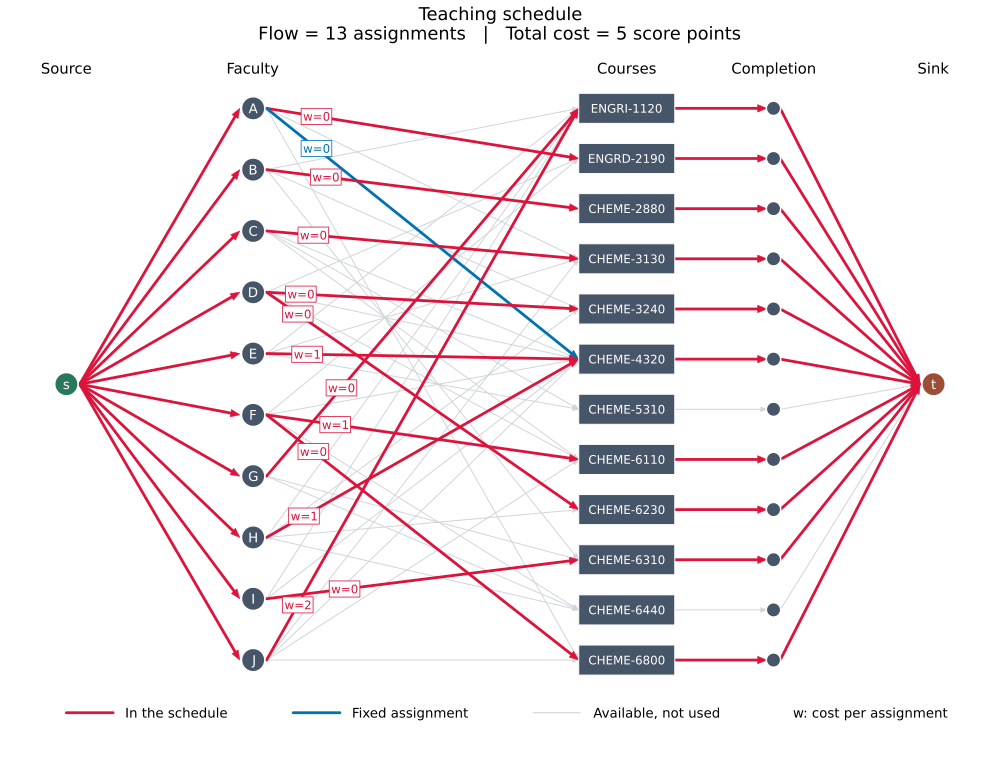

In [15]:
# Compare the selected assignments with the available network -
# Supplying result adds the optimal flows; fixed assignments remain marked in blue.
plot_teaching_flow(department, network, result; title = "Teaching schedule")

The completion arrows of CHEME 5310 and CHEME 6440 stay gray because those electives do not run in the displayed schedule. CHEME 6310 and CHEME 6800 take the two assignments remaining after the required courses are staffed. These numerical results describe the supplied data; changing a load, staffing rule, or score may change the result.

### Things to think about

__Does the minimum-cost schedule give a fair teaching allocation?__ J, the newest faculty member, receives the only assignment with a score of 2 in the displayed schedule. Suppose the chair wants J to receive a course with a score of at most 1 while preserving every teaching load and staffing requirement. Use J's survey row to identify the allowed alternatives, then use the schedule to identify whose assignments would also need to change. Explain why improving J's assignment must be judged together with the effects on those other faculty members. State whether the objective we minimized expresses the chair's preference, and what evidence you would need before accepting a higher total cost to satisfy it.

___

## Task 3: Change the data and predict the schedule

In this task, we change the department's data and test how the optimal schedule responds. We will first change the cost of an existing assignment, then change a teaching load. Before each solve, predict which assignments can still be made and which the objective will favor.

Each helper returns a changed copy, so `department` remains our baseline. The functions give us two kinds of intervention:

* [The `with_preference(...)` function](docs/scenario_helpers.md) changes a survey score; changing a blank to a score also adds an option. For an existing option, [the `with_cost(...)` function](docs/scenario_helpers.md) sets any cost, including a bonus below zero.
* [The `with_load(...)` function](docs/scenario_helpers.md), [the `with_staffing(...)` function](docs/scenario_helpers.md), and [the `with_fixed(...)` function](docs/scenario_helpers.md) change bounds: a load, a staffing limit, or a fixed assignment.

### A change in cost

__Predict:__ C now rates thermodynamics a 3 instead of a 0. Does C keep CHEME 3130, and what happens to the total cost of 5?

The next cell stores the changed data in `scenario`, rebuilds its network, and solves it with [the `solve_min_cost_flow(...)` function](docs/solve_min_cost_flow.md). This helper assembles the arrays we constructed by hand in Task 2 before calling the same solver. The figure uses the changed survey scores and shows the new total cost. When trying another intervention, replace the `scenario` expression and update `change`, then rerun the whole cell so the network and solution reflect that intervention:

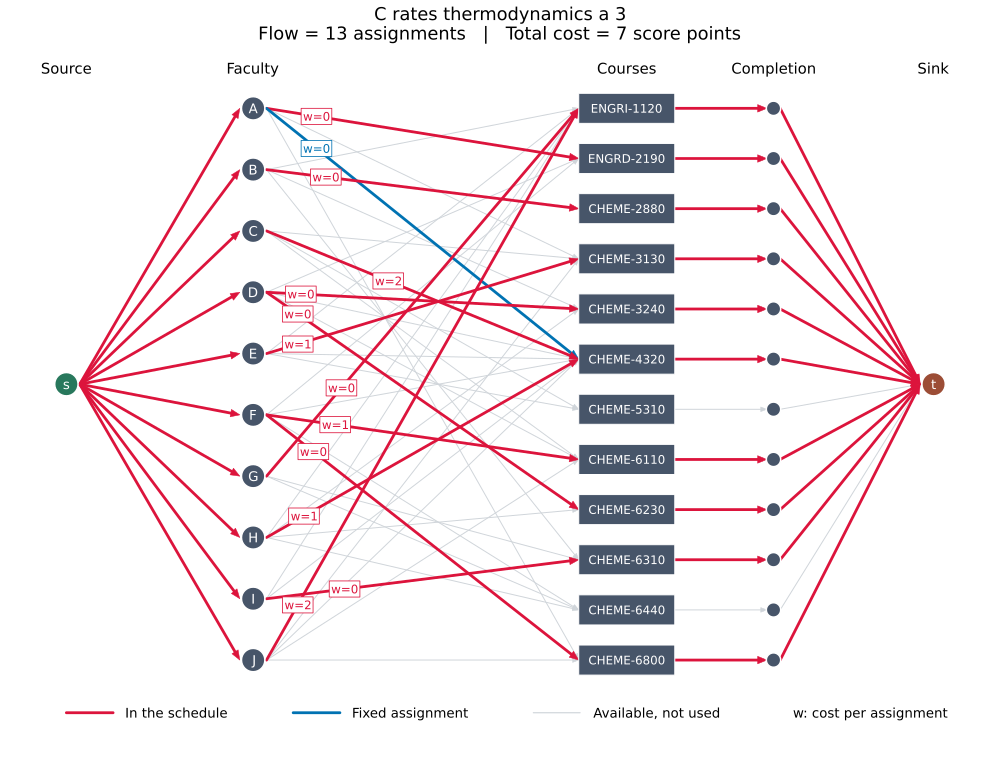

In [16]:
# Change one survey response in a copy of the baseline department -
change = "C rates thermodynamics a 3"; # describe the experiment in the figure title
scenario = with_preference(department, "C", "CHEME-3130", 3); # score points; the option remains available

# Predict the assignment changes, then rebuild and solve the modified model -
scenario_network = build_teaching_network(scenario); # transfer the new score to its edge cost
scenario_result = solve_min_cost_flow(scenario_network); # assemble fresh arrays and solve

# Display the schedule and cost, or the solver status if no optimum is available -
plot_teaching_flow(scenario, scenario_network, scenario_result; title = change)

In the displayed solution, C and E swap: E takes thermodynamics with a 1, and C joins the capstone with a 2. The total is 7. Retaining the entire baseline schedule would instead raise its cost from 5 to 8 because C's selected edge became three points more expensive. The swap therefore saves one point relative to keeping that schedule. The available edges and their bounds have not changed, so this comparison is between schedules that were already feasible.

### A change in a bound

__Predict:__ B goes on sabbatical, so B's load drops to 0. The totals still fit, with 12 assignments for 11 to 15 positions. Is there still a schedule?

This cell starts again from `department`, so it does not retain C's changed score. B's load becomes zero, which fixes the source-to-B flow at zero, and the required total flow falls to 12. The course staffing requirements and the set of eligible faculty–course pairings stay the same. We solve this new network and let the figure report whether a schedule exists:

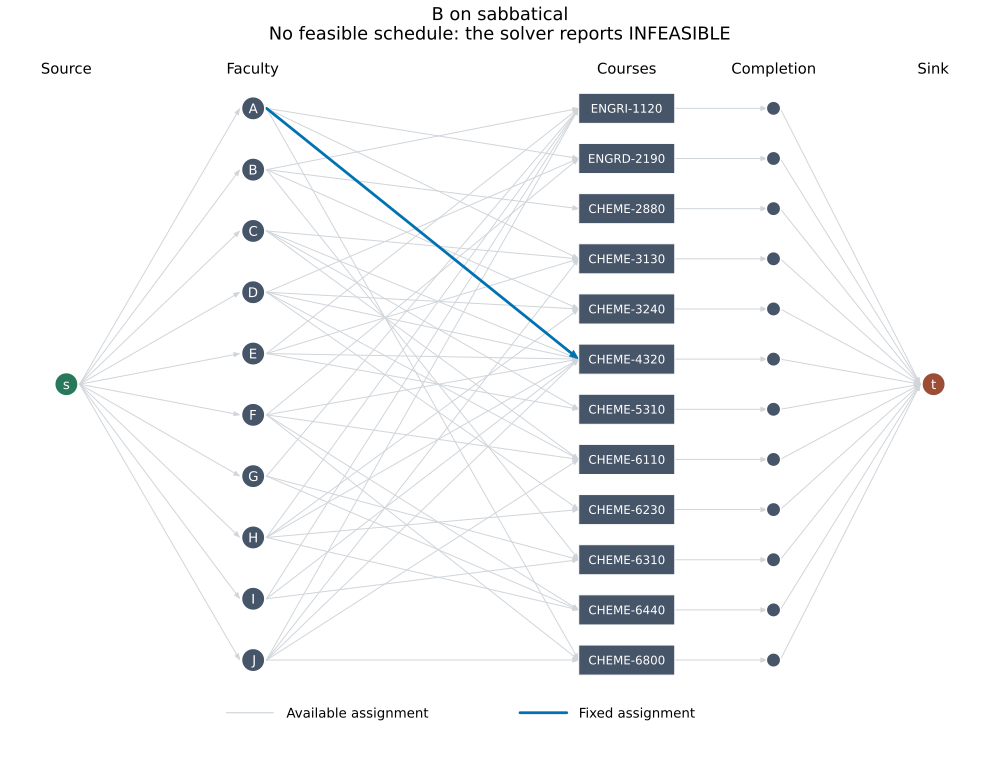

In [17]:
# Start a separate experiment from the baseline department -
change = "B on sabbatical"; # describe the experiment in the figure title
scenario = with_load(department, "B", 0); # zero assignments; C's baseline score is restored

# Predict feasibility, then rebuild with the new load and required total flow -
scenario_network = build_teaching_network(scenario); # B's load-edge bounds become zero; F becomes 12
scenario_result = solve_min_cost_flow(scenario_network); # the solver checks all constraints together

# For an infeasible result, the plot reports the status and shows the unsolved network -
plot_teaching_flow(scenario, scenario_network, scenario_result; title = change)

The solver reports `INFEASIBLE`, so the figure shows the available network without a solved flow. Only B can teach CHEME 2880, and its staffing edge still requires one assignment. But B receives no flow from the source and therefore cannot send any flow to the course. These two requirements cannot hold together. The totals check missed this because it ignores who can teach which course.

### Things to think about

Try each change in the cells above, updating `change` and predicting the result before you run it:

* __Question:__ Set C's thermodynamics score to 1 instead of 3 with `with_preference(department, "C", "CHEME-3130", 1)`. Does anyone move? At what score does C give up the course?
* __Question:__ Require J to teach thermodynamics with `with_fixed(department, "J", "CHEME-3130")`, then instead offer J a bonus with `with_cost(department, "J", "CHEME-3130", -1.0)`. How do the two schedules differ, and how large must the bonus be before the solver takes it?
* __Question:__ Fix the sabbatical by letting G teach CHEME 2880 with a score of 2: `with_preference(with_load(department, "B", 0), "G", "CHEME-2880", 2)`. Who moves, and which elective is cancelled?

___

## Summary

We modeled teaching assignments as a minimum-cost flow, solved the linear program, and changed its costs and bounds to see how the schedule responds.

> __Key Takeaways__
>
> * __Department rules as bounds and costs:__ We translated exact teaching loads, staffing limits, and fixed assignments into lower bounds and capacities, and we used survey scores as costs. A blank survey entry removed an option entirely, while a poor score only made it expensive.
>
> * __Building and solving the linear program:__ We assembled the incidence matrix, required net flows, costs, and bounds and solved for the lowest-cost schedule. Because the data are whole numbers, the solver returned whole assignments, which we checked against the department's rules.
>
> * __Changing costs and bounds:__ We predicted how the schedule would respond to each change and checked the prediction against the flow diagram. A change in cost reranked the same feasible schedules, while a change in a bound could remove schedules altogether, as the sabbatical did.

In week 6, we apply the same tools to metabolism: flux balance analysis uses a linear program with balance constraints and flux bounds to predict how a cell routes its reactions.

___